## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Normalização e Padronização de Dados

A base de alguns algoritmos de aprendizado de máquina é o cálculo de distâncias. Se os dados não estivem na mesma escala é possível que um valor maior interfira no processo de treinamento.

Por conta disso existe a necessidade de normalizar ou padronizar os dados.

## Exemplo Numérico

Considere um conjunto de dados com dois atributos numéricos, um relacionado a idade e outro ao salário de uma pessoa. 

| Atributo | Exemplo de faixa |
|---|---|
| Idade | 16 a 80 |
| Salário | 1500 a 30000 |

Algoritmos baseados em distância, como KNN ou K-Means, podem apresentar resultados insatisfatórios, pois o atributo com maior escala numérica tende a dominar o cálculo.

A distância Euclidiana é definida pela seguinte equação:

$$
d(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

Se um atributo varia de 0 a 1 e outro varia de 0 a 100000, o segundo terá muito mais peso na distância, mesmo que não seja necessariamente mais importante.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
dados = pd.DataFrame({
    'idade': [16, 18, 20, 25, 30, 35, 40, 45, 50, 60],
    'salario': [1500, 1700, 1820, 1980, 2500, 3200, 4500, 7000, 12000, 20000]
})

dados

,idade,salario
0,16,1500
1,18,1700
2,20,1820
3,25,1980
4,30,2500
5,35,3200
6,40,4500
7,45,7000
8,50,12000
9,60,20000


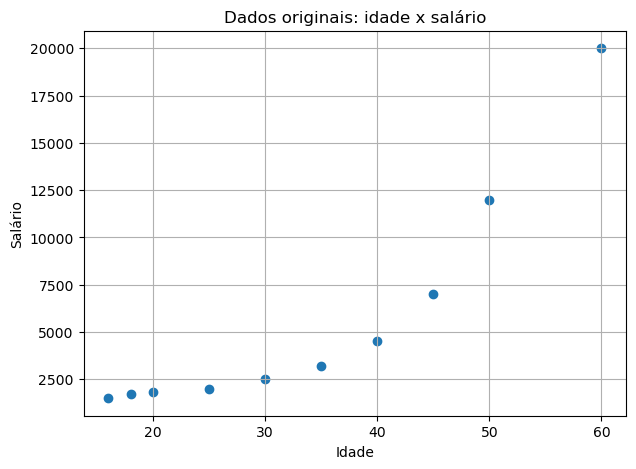

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(dados['idade'], dados['salario'])
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.title('Dados originais: idade x salário')
plt.grid(True)
plt.show()

O atributo salário possui valores numericamente superiores ao atributo idade.

# Normalização de Dados

## Normalização Min-Max

A **normalização Min-Max** transforma os dados para uma faixa específica, normalmente entre 0 e 1.


$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

onde:

- $x$ é o valor original;
- $x_{min}$ é o menor valor do atributo;
- $x_{max}$ é o maior valor do atributo;
- $x'$ é o valor normalizado.

## Normalizando os Atributos Idade e Salário sem o uso de Bibliotecas

In [21]:
X = dados[['idade', 'salario']].values

minimo = np.min(X, axis=0)
maximo = np.max(X, axis=0)

X_normalizado_manual = (X - minimo) / (maximo - minimo)

pd.DataFrame(X_normalizado_manual, columns=['idade_normalizada', 'salario_normalizado'])

,idade_normalizada,salario_normalizado
0,0.0000,0.0000
1,0.0455,0.0108
2,0.0909,0.0173
3,0.2045,0.0259
4,0.3182,0.0541
5,0.4318,0.0919
6,0.5455,0.1622
7,0.6591,0.2973
8,0.7727,0.5676
9,1.0000,1.0000


In [22]:
print('Mínimos originais:')
print(minimo)

print('\nMáximos originais:')
print(maximo)

print('\nMínimos após normalização:')
print(np.min(X_normalizado_manual, axis=0))

print('\nMáximos após normalização:')
print(np.max(X_normalizado_manual, axis=0))

Mínimos originais:
[  16 1500]

Máximos originais:
[   60 20000]

Mínimos após normalização:
[0. 0.]

Máximos após normalização:
[1. 1.]


Depois da normalização Min-Max, os menores valores ficam iguais a 0 e os maiores valores ficam iguais a 1.

## Normalizando os Atributos Idade e Salário com o uso da Biblioteca Scikit-Learn

Para normalizar um atributo com `scikit-learn` é utilizada a classe `MinMaxScaler`.

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
X_normalizado = scaler_minmax.fit_transform(X)

pd.DataFrame(X_normalizado, columns=['idade_normalizada', 'salario_normalizado'])

,idade_normalizada,salario_normalizado
0,0.0000,0.0000
1,0.0455,0.0108
2,0.0909,0.0173
3,0.2045,0.0259
4,0.3182,0.0541
5,0.4318,0.0919
6,0.5455,0.1622
7,0.6591,0.2973
8,0.7727,0.5676
9,1.0000,1.0000


O método `fit_transform()` faz duas coisas:

1. `fit()` calcula os parâmetros da transformação (valor mínimo e valor máximo);
2. `transform()` aplica a transformação aos dados.

## Interpretação Matemática da Normalização

Com a normalização queremos saber qual a posição de um determinado valor dentro do intervalo.

Exemplo:

* 0 - mínimo

* 1 - máximo

* 0.5 - meio do intervalo

# Padronização dos Dados

A **padronização**, também chamada de **Z-score normalization** ou **Standardization**, transforma os dados para que tenham:

- média igual a 0;
- desvio padrão igual a 1.

A equação da padronização é:

$$
z = \frac{x - \mu}{\sigma}
$$

onde:

- $x$ é o valor original;
- $\mu$ é a média dos dados;
- $\sigma$ é o desvio padrão dos dados;
- $z$ é o valor padronizado.

## Interpretação Matemática da Padronização

O valor padronizado indica quantos desvios padrão o ponto está distante da média.

Por exemplo:

| Valor de z | Interpretação |
|---|---|
| 0 | O valor está exatamente na média |
| 1 | O valor está 1 desvio padrão acima da média |
| -1 | O valor está 1 desvio padrão abaixo da média |
| 2 | O valor está 2 desvios padrão acima da média |

## Padronizando os Atributos Idade e Salário sem o uso de Bibliotecas

In [24]:
media = np.mean(X, axis=0)
desvio = np.std(X, axis=0)

X_padronizado_manual = (X - media) / desvio

pd.DataFrame(X_padronizado_manual, columns=['idade_padronizada', 'salario_padronizado'])

,idade_padronizada,salario_padronizado
0,-1.2776,-0.7213
1,-1.1349,-0.6863
2,-0.9921,-0.6653
3,-0.6352,-0.6373
4,-0.2784,-0.5462
5,0.0785,-0.4237
6,0.4354,-0.1961
7,0.7923,0.2416
8,1.1492,1.1169
9,1.8629,2.5175


In [25]:
print('Média dos dados originais:')
print(media)

print('\nDesvio padrão dos dados originais:')
print(desvio)

print('\nMédia após padronização:')
print(np.mean(X_padronizado_manual, axis=0))

print('\nDesvio padrão após padronização:')
print(np.std(X_padronizado_manual, axis=0))

Média dos dados originais:
[  33.9 5620. ]

Desvio padrão dos dados originais:
[  14.01035331 5711.99439776]

Média após padronização:
[6.66133815e-17 4.44089210e-17]

Desvio padrão após padronização:
[1. 1.]


Após a padronização, cada atributo fica com média próxima de 0 e desvio padrão próximo de 1.

## Padronizando os Atributos Idade e Salário com o uso da Biblioteca Scikit-Learn

Para padronizar um atributo com `scikit-learn` é utilizada a classe `StandardScaler`.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler_padrao = StandardScaler()
X_padronizado = scaler_padrao.fit_transform(X)

pd.DataFrame(X_padronizado, columns=['idade_padronizada', 'salario_padronizado'])

,idade_padronizada,salario_padronizado
0,-1.2776,-0.7213
1,-1.1349,-0.6863
2,-0.9921,-0.6653
3,-0.6352,-0.6373
4,-0.2784,-0.5462
5,0.0785,-0.4237
6,0.4354,-0.1961
7,0.7923,0.2416
8,1.1492,1.1169
9,1.8629,2.5175


O método `fit_transform()` faz duas coisas:

1. `fit()` calcula os parâmetros da transformação (média e desvio padrão);
2. `transform()` aplica a transformação aos dados.

# Comparação entre a Normalização e a Padronização

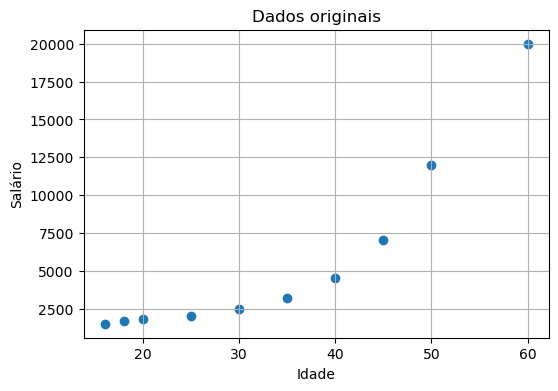

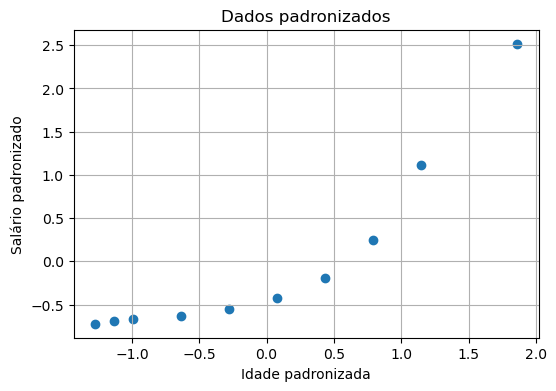

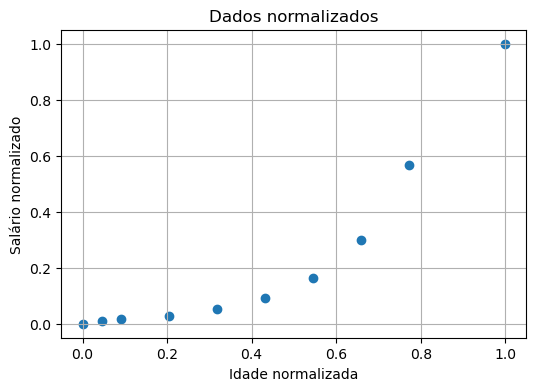

In [27]:
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.title('Dados originais')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(X_padronizado[:, 0], X_padronizado[:, 1])
plt.xlabel('Idade padronizada')
plt.ylabel('Salário padronizado')
plt.title('Dados padronizados')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(X_normalizado[:, 0], X_normalizado[:, 1])
plt.xlabel('Idade normalizada')
plt.ylabel('Salário normalizado')
plt.title('Dados normalizados')
plt.grid(True)
plt.show()

# Métodos `fit`, `transform` e `fit_transform`

## `fit()`
Calcula os parâmetros da transformação.

No caso da padronização, calcula:

$$
\mu \quad \text{e} \quad \sigma
$$

No caso da normalização, calcula:

$$
x_{min} \quad \text{e} \quad x_{max}
$$



## `transform()`
Aplica a transformação usando os parâmetros já calculados.

## `fit_transform()`
Executa `fit()` e `transform()` em uma única chamada.

In [28]:
scaler = StandardScaler()

# Calcula média e desvio padrão
scaler.fit(X)

print('Média calculada pelo scaler:')
print(scaler.mean_)

print('\nDesvio padrão calculado pelo scaler:')
print(scaler.scale_)

# Aplica a transformação
X_transformado = scaler.transform(X)

pd.DataFrame(X_transformado, columns=['idade_padronizada', 'salario_padronizado'])

Média calculada pelo scaler:
[  33.9 5620. ]

Desvio padrão calculado pelo scaler:
[  14.01035331 5711.99439776]


,idade_padronizada,salario_padronizado
0,-1.2776,-0.7213
1,-1.1349,-0.6863
2,-0.9921,-0.6653
3,-0.6352,-0.6373
4,-0.2784,-0.5462
5,0.0785,-0.4237
6,0.4354,-0.1961
7,0.7923,0.2416
8,1.1492,1.1169
9,1.8629,2.5175


# Normalizando e Padronizando os Dados de Treinamento e de Teste (cuidados!)

Um erro comum é ajustar o escalonador separadamente nos dados de treino e teste.

Errado:

```python
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
```

Correto:

```python
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
```

O conjunto de teste deve simular dados novos. Portanto, ele não deve influenciar os parâmetros da transformação.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)

scaler = StandardScaler()

X_train_pad = scaler.fit_transform(X_train)
X_test_pad = scaler.transform(X_test)

print('Dados de treino padronizados:')
print(X_train_pad)

print('\nDados de teste padronizados:')
print(X_test_pad)

Dados de treino padronizados:
[[-1.23104593 -0.6695159 ]
 [ 0.78429539  0.22549668]
 [-0.95306782 -0.61744245]
 [ 1.82671331  2.34098096]
 [-0.25812253 -0.50678634]
 [-0.60559517 -0.59140572]
 [ 0.43682275 -0.18132722]]

Dados de teste padronizados:
[[ 1.13176803  1.03914448]
 [-1.09205687 -0.63696999]
 [ 0.08935011 -0.39287565]]


A diferença pode variar a cada conjunto de dados, mas a ideia principal é que o escalonamento evita que uma variável domine a distância apenas por estar em uma escala numérica maior.

## Exemplo em Python sem e com Padronização de Dados (modelo SVM com dados aleatórios)

In [36]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [76]:
# Gerando dados aleatórios
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=0.5,
    random_state=42
)


# Artificialmente mudando a escala de uma das variáveis
X[:, 1] = X[:, 1] * 1000

In [77]:
# Verifiando o mim e o max dos atributos
print(f'X1 -> min: {X[:,0].min()} max: {X[:,0].max()}')
print(f'X2 -> min: {X[:,1].min()} max: {X[:,1].max()}')


X1 -> min: -2.9727177022170643 max: 3.638715401007325
X2 -> min: -2350.971449868199 max: 2842.864069511592


In [78]:
# Separando os dados de treino e de teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Exemplo sem Padronização de Dados

In [79]:
# Instanciando o modelo SVM
svm = SVC(kernel='rbf')

In [80]:
# Treinando o modelo SVM
svm.fit(X_treino, y_treino)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [81]:
# Relatório de desempenho (classification report)
y_pred = svm.predict(X_teste)

print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.80      0.73       147
           1       0.76      0.62      0.68       153

    accuracy                           0.71       300
   macro avg       0.71      0.71      0.71       300
weighted avg       0.72      0.71      0.70       300



## Exemplo com Padronização de Dados

In [82]:
std = StandardScaler()

X_treino_padronizado = std.fit_transform(X_treino)
X_teste_padronizado = std.transform(X_teste)

In [83]:
svm.fit(X_treino_padronizado, y_treino)

y_pred = svm.predict(X_teste_padronizado)

print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       147
           1       0.98      0.82      0.90       153

    accuracy                           0.90       300
   macro avg       0.91      0.90      0.90       300
weighted avg       0.92      0.90      0.90       300



# Pipeline Recomendado

A forma mais segura de usar escalonamento com modelos de aprendizado de máquina é por meio de `Pipeline`.

Isso evita vazamento de dados entre treino e teste e facilita a validação cruzada.

In [ ]:
from sklearn.pipeline import Pipeline

In [84]:
# Pipeline de treinamento (modelo SVM com dados padronizados)
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

pipeline_svm.fit(X_treino, y_treino)
y_pred = pipeline_svm.predict(X_teste)

print(classification_report(y_teste, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       147
           1       0.98      0.82      0.90       153

    accuracy                           0.90       300
   macro avg       0.91      0.90      0.90       300
weighted avg       0.92      0.90      0.90       300



## Observação sobre o uso de `StandardScaler`

Quando houver dúvida, a padronização com `StandardScaler` costuma ser uma boa primeira escolha, especialmente para algoritmos baseados em distância, margem, gradiente ou PCA.

# Algoritmos que Geralmente Precisam de Scalonamento

| Algoritmo | Precisa escalar? | Observação |
|---|---|---|
| KNN | Sim | Usa distância |
| K-Means | Sim | Usa distância |
| SVM | Sim | Sensível à escala |
| Regressão Logística | Recomendado | Ajuda na otimização |
| MLP / Redes Neurais | Sim | Ajuda no treinamento |
| PCA | Sim | Evita dominância de variáveis com maior variância |
| Regressão Linear | Recomendado em alguns casos | Especialmente com regularização |
| Árvore de Decisão | Geralmente não | Baseia-se em divisões por limiar |
| Random Forest | Geralmente não | Baseia-se em árvores |
| Gradient Boosting | Geralmente não | Baseia-se em árvores |

# Sensibilidade a Valores Extremos (outliers)

A normalização Min-Max pode ser bastante afetada por valores extremos.

In [85]:
dados_outlier = np.array([[10], [20], [30], [40], [50], [1000]])

scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

out_minmax = scaler_minmax.fit_transform(dados_outlier)
out_standard = scaler_standard.fit_transform(dados_outlier)

comparacao_outlier = pd.DataFrame({
    'original': dados_outlier.flatten(),
    'minmax': out_minmax.flatten(),
    'standard': out_standard.flatten()
})

comparacao_outlier

,original,minmax,standard
0,10,0.0000,-0.5022
1,20,0.0101,-0.4746
2,30,0.0202,-0.4469
3,40,0.0303,-0.4193
4,50,0.0404,-0.3916
5,1000,1.0000,2.2346


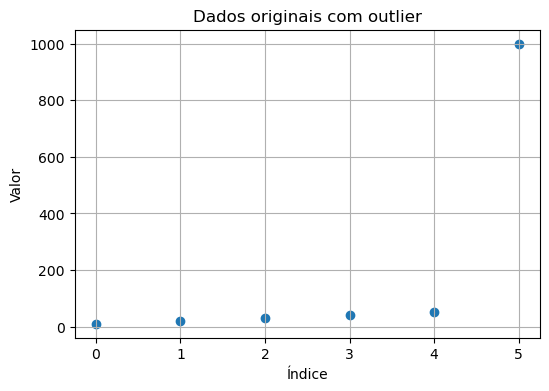

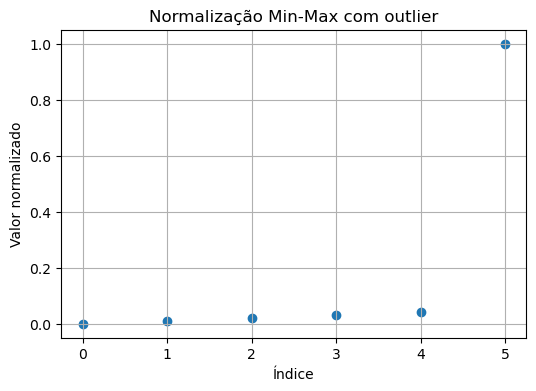

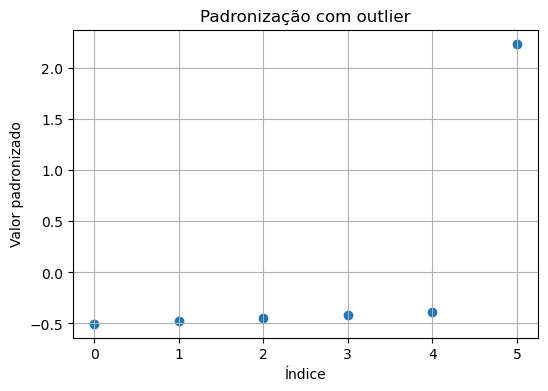

In [86]:
plt.figure(figsize=(6, 4))
plt.scatter(range(len(dados_outlier)), dados_outlier.flatten())
plt.title('Dados originais com outlier')
plt.xlabel('Índice')
plt.ylabel('Valor')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(range(len(out_minmax)), out_minmax.flatten())
plt.title('Normalização Min-Max com outlier')
plt.xlabel('Índice')
plt.ylabel('Valor normalizado')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(range(len(out_standard)), out_standard.flatten())
plt.title('Padronização com outlier')
plt.xlabel('Índice')
plt.ylabel('Valor padronizado')
plt.grid(True)
plt.show()

Quando há outliers muito fortes, pode ser interessante avaliar outras técnicas, como `RobustScaler`, que usa mediana e intervalo interquartil.

## RobustScaler

O `RobustScaler` é menos sensível a outliers porque usa:

- mediana;
- intervalo interquartil.

A ideia geral é:

$$
x' = \frac{x - \text{mediana}}{IQR}
$$

onde:

$$
IQR = Q_3 - Q_1
$$

In [88]:
from sklearn.preprocessing import RobustScaler

scaler_robusto = RobustScaler()
out_robust = scaler_robusto.fit_transform(dados_outlier)

comparacao_outlier['robust'] = out_robust.flatten()
comparacao_outlier

,original,minmax,standard,robust
0,10,0.0000,-0.5022,-1.0
1,20,0.0101,-0.4746,-0.6
2,30,0.0202,-0.4469,-0.2
3,40,0.0303,-0.4193,0.2
4,50,0.0404,-0.3916,0.6
5,1000,1.0000,2.2346,38.6


# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

* Mathematics for Machine Learning (disponível no Moodle).